# Notebook 01 — Feature Engineering
## Robinhood Engagement Analytics
---
**Goal:** Build every engagement metric and product characteristic variable that will enter the regression models.

This notebook produces two outputs saved to disk:
- `data/analysis_raw.csv` — full feature panel
- `data/analysis_winsorized.csv` — outlier-treated version for modeling

---
## Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# ── Local path — adjust to wherever your CSVs live ───────────────────────────
project_root = '/Users/vando/Documents/USC/Career Center/Robinhood-Engagement-Analytics-1'
data_path = os.path.join(project_root, 'popularity_export')
os.makedirs(data_path, exist_ok=True)
os.makedirs(project_root, exist_ok=True)
print(f'Using project root: {project_root}')

STOCKS = ['F', 'GE', 'AAPL', 'MSFT', 'AAL', 'DIS']
ALL    = STOCKS + ['SPY']
print('Setup complete.')

Using project root: /Users/vando/Documents/USC/Career Center/Robinhood-Engagement-Analytics-1
Setup complete.


---
## Step 1 — Load the Master Panel

This is `daily_growth_returns_of_top_stocks` from your Robinhood class notebook — the merged panel of user holdings growth rates and stock returns.

**If you haven't saved it yet**, re-run your Robinhood notebook and add this cell at the end:
```python
daily_growth_returns_of_top_stocks.to_csv('data/master_panel.csv')
```

In [43]:
# ── Load master panel ────────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(project_root, 'master_panel.csv'), index_col=0, parse_dates=True)
df.sort_index(inplace=True)

# Verify
print(df.columns.tolist())

print(f'Master panel shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head()

['F_avg_growth_rate_users', 'GE_avg_growth_rate_users', 'AAPL_avg_growth_rate_users', 'MSFT_avg_growth_rate_users', 'AAL_avg_growth_rate_users', 'DIS_avg_growth_rate_users', 'SPY_avg_growth_rate_users', "('F_returns', 'F')", "('GE_returns', 'GE')", "('AAPL_returns', 'AAPL')", "('MSFT_returns', 'MSFT')", "('AAL_returns', 'AAL')", "('DIS_returns', 'DIS')"]
Master panel shape: (526, 13)
Date range: 2018-05-03 00:00:00 to 2020-08-12 00:00:00

Columns:
['F_avg_growth_rate_users', 'GE_avg_growth_rate_users', 'AAPL_avg_growth_rate_users', 'MSFT_avg_growth_rate_users', 'AAL_avg_growth_rate_users', 'DIS_avg_growth_rate_users', 'SPY_avg_growth_rate_users', "('F_returns', 'F')", "('GE_returns', 'GE')", "('AAPL_returns', 'AAPL')", "('MSFT_returns', 'MSFT')", "('AAL_returns', 'AAL')", "('DIS_returns', 'DIS')"]


,F_avg_growth_rate_users,GE_avg_growth_rate_users,AAPL_avg_growth_rate_users,MSFT_avg_growth_rate_users,AAL_avg_growth_rate_users,DIS_avg_growth_rate_users,SPY_avg_growth_rate_users,"('F_returns', 'F')","('GE_returns', 'GE')","('AAPL_returns', 'AAPL')","('MSFT_returns', 'MSFT')","('AAL_returns', 'AAL')","('DIS_returns', 'DIS')"
Date,,,,,,,,,,,,,
2018-05-03,0.001189,-0.001179,-0.039831,0.005241,0.006223,0.004178,0.006993,-0.000892,-0.017631,0.001812,0.005989,-0.003078,-0.008633
2018-05-04,-0.002037,-0.000022,-0.014423,-0.005204,-0.004134,0.002206,-0.001533,0.014286,0.012204,0.039233,0.011587,0.017811,0.024200
2018-05-16,-0.000867,0.002323,0.001899,0.003112,-0.010385,-0.002528,0.000528,0.016043,0.021754,0.009333,0.002580,0.020144,0.020599
2018-06-12,0.001391,0.002063,-0.000852,0.006908,-0.005598,-0.005065,0.004161,0.006650,0.000000,0.005491,0.002573,-0.016984,-0.000192
2018-06-13,-0.000840,-0.000253,-0.001427,0.002982,0.025498,-0.006910,0.003053,-0.007432,-0.006437,-0.008217,-0.004541,-0.011288,0.018978


In [44]:
# ── Load raw holdings (levels, not growth rates) ─────────────────────────────
# This is daily_holdings_of_all_stocks from your Robinhood notebook
# Save it if you haven't: daily_holdings_of_all_stocks.to_csv('data/avg_daily_rh_user_holding.csv')

holdings_raw = pd.read_csv(os.path.join(data_path, 'avg_daily_rh_user_holding.csv'),
                            index_col=0, parse_dates=True)
holdings_raw.sort_index(inplace=True)

hold_cols = [f'{t}_avg_users_holding' for t in ALL if f'{t}_avg_users_holding' in holdings_raw.columns]
holdings  = holdings_raw[hold_cols].copy()

print(f'Raw holdings shape: {holdings.shape}')
holdings.describe().round(0)

Raw holdings shape: (835, 7)


,F_avg_users_holding,GE_avg_users_holding,AAPL_avg_users_holding,MSFT_avg_users_holding,AAL_avg_users_holding,DIS_avg_users_holding,SPY_avg_users_holding
count,818.0,818.0,818.0,818.0,818.0,818.0,777.0
mean,343949.0,327106.0,246143.0,241277.0,100225.0,197159.0,46024.0
std,242395.0,205769.0,103044.0,120655.0,205935.0,175318.0,25201.0
min,130622.0,134057.0,140816.0,110980.0,3748.0,59936.0,22667.0
25%,187460.0,190166.0,201853.0,162674.0,6931.0,67474.0,30277.0
50%,254597.0,269013.0,218707.0,197361.0,9192.0,132611.0,36070.0
75%,330758.0,310197.0,237522.0,265290.0,11415.0,203620.0,47103.0
max,943957.0,862544.0,720906.0,654240.0,659935.0,630863.0,118456.0


---
## Step 2 — Engagement Metrics

We build **four** engagement measures per stock. Each captures a different dimension of user attention.

| Metric | Definition | Business Meaning |
|--------|-----------|------------------|
| Delta Holdings | `holdings.diff()` | Net user flow in/out of stock |
| Growth Rate | `holdings.pct_change()` | Percentage change in user base |
| Attention Spike | Rolling z-score > 2 | Binary flag for abnormal attention days |

### 2a — Delta Holdings (Primary Dependent Variable)

In [45]:
# Day-over-day change: how many more/fewer users hold the stock vs yesterday
# .diff() = today - yesterday  (same as holdings_t - holdings_{t-1})
delta_holdings = holdings.diff()
delta_holdings.columns = [c.replace('_avg_users_holding', '_delta_holdings') for c in delta_holdings.columns]

print('Delta holdings — summary stats:')
delta_holdings.describe().round(1)

Delta holdings — summary stats:


,F_delta_holdings,GE_delta_holdings,AAPL_delta_holdings,MSFT_delta_holdings,AAL_delta_holdings,DIS_delta_holdings,SPY_delta_holdings
count,813.0,813.0,813.0,813.0,813.0,813.0,764.0
mean,949.4,878.3,689.1,646.4,780.7,661.8,122.1
std,2565.2,2142.1,2149.7,1773.1,2887.3,1804.6,244.9
min,-3187.7,-1924.0,-6005.9,-4179.6,-5278.3,-4124.8,-184.6
25%,1.3,-1.0,-56.8,-0.6,-9.0,-2.8,0.0
50%,216.8,163.0,60.3,182.3,2.7,95.8,38.5
75%,725.6,772.9,645.3,687.1,52.3,474.4,125.6
max,32613.4,19381.8,25691.4,32579.2,33092.5,17136.6,2189.2


### 2b — Holdings Growth Rate (Alternate Dependent Variable)

In [46]:
# Percentage change — your exact pct_change() pattern from the Robinhood notebook
growth_rate = holdings.pct_change(fill_method=None)
growth_rate.columns = [c.replace('_avg_users_holding', '_growth_rate_holdings') for c in growth_rate.columns]

print('Growth rate — summary stats:')
growth_rate.describe().round(4)

Growth rate — summary stats:


,F_growth_rate_holdings,GE_growth_rate_holdings,AAPL_growth_rate_holdings,MSFT_growth_rate_holdings,AAL_growth_rate_holdings,DIS_growth_rate_holdings,SPY_growth_rate_holdings
count,813.0000,813.0000,813.0000,813.0000,813.0000,813.0000,764.0000
mean,0.0023,0.0023,0.0019,0.0021,0.0066,0.0028,0.0021
std,0.0049,0.0047,0.0053,0.0043,0.0237,0.0065,0.0037
min,-0.0039,-0.0067,-0.0398,-0.0131,-0.0211,-0.0152,-0.0048
25%,0.0000,-0.0000,-0.0003,-0.0000,-0.0010,-0.0000,0.0000
50%,0.0009,0.0007,0.0003,0.0010,0.0002,0.0009,0.0011
75%,0.0030,0.0028,0.0030,0.0034,0.0045,0.0031,0.0030
max,0.0602,0.0440,0.0411,0.0547,0.2142,0.0592,0.0350


### 2c — Attention Spike Flags (Binary)

In [47]:
# Flag days where holdings growth exceeds 2 std deviations above the 30-day rolling mean
# These are days of ABNORMAL user attention — the most analytically interesting days

spike_flags = pd.DataFrame(index=growth_rate.index)

for ticker in ALL:
    col    = f'{ticker}_growth_rate_holdings'
    if col not in growth_rate.columns:
        continue
    series = growth_rate[col]
    roll_m = series.rolling(30).mean()
    roll_s = series.rolling(30).std()
    # 1 = attention spike day, 0 = normal day
    spike_flags[f'{ticker}_spike'] = ((series - roll_m) / roll_s > 2).astype(int)

print('Attention spike days per stock:')
print(spike_flags.sum())

Attention spike days per stock:
F_spike       41
GE_spike      39
AAPL_spike    45
MSFT_spike    43
AAL_spike     42
DIS_spike     41
SPY_spike     36
dtype: int64


---
## Step 3 — Product Characteristics

These are the **independent variables** — the stock features that may or may not drive user engagement.

| Characteristic | Window | Business Meaning |
|---------------|--------|------------------|
| Daily return | 1 day | Did the stock go up or down today? |
| Volatility | 20-day rolling std | How risky/exciting is this stock? |
| Momentum (5d) | 5-day cumulative return | Short-term price streak |
| Momentum (30d) | 30-day cumulative return | Longer-term trend |
| Drawdown | 90-day rolling | How far from recent peak? |

### 3a — Daily Returns (already in your data)

In [48]:
ret_cols = [c for c in df.columns if 'return' in c.lower()]
print(ret_cols)
returns = df[ret_cols].copy()

print('Returns — confirming small decimal values (e.g. 0.02 = 2% return):')
returns.describe().round(4) 

["('F_returns', 'F')", "('GE_returns', 'GE')", "('AAPL_returns', 'AAPL')", "('MSFT_returns', 'MSFT')", "('AAL_returns', 'AAL')", "('DIS_returns', 'DIS')"]
Returns — confirming small decimal values (e.g. 0.02 = 2% return):


,"('F_returns', 'F')","('GE_returns', 'GE')","('AAPL_returns', 'AAPL')","('MSFT_returns', 'MSFT')","('AAL_returns', 'AAL')","('DIS_returns', 'DIS')"
count,526.0000,526.0000,526.0000,526.0000,526.0000,526.0000
mean,-0.0004,-0.0007,0.0019,0.0017,-0.0011,0.0009
std,0.0273,0.0333,0.0229,0.0214,0.0471,0.0221
min,-0.1101,-0.1516,-0.1286,-0.1474,-0.2522,-0.1298
25%,-0.0117,-0.0159,-0.0077,-0.0072,-0.0180,-0.0078
50%,0.0000,-0.0020,0.0024,0.0020,-0.0016,0.0009
75%,0.0105,0.0145,0.0123,0.0107,0.0155,0.0095
max,0.2344,0.1473,0.1198,0.1422,0.4110,0.1441


In [49]:
returns

,"('F_returns', 'F')","('GE_returns', 'GE')","('AAPL_returns', 'AAPL')","('MSFT_returns', 'MSFT')","('AAL_returns', 'AAL')","('DIS_returns', 'DIS')"
Date,,,,,,
2018-05-03,-0.000892,-0.017631,0.001812,0.005989,-0.003078,-0.008633
2018-05-04,0.014286,0.012204,0.039233,0.011587,0.017811,0.024200
2018-05-16,0.016043,0.021754,0.009333,0.002580,0.020144,0.020599
2018-06-12,0.006650,0.000000,0.005491,0.002573,-0.016984,-0.000192
2018-06-13,-0.007432,-0.006437,-0.008217,-0.004541,-0.011288,0.018978
...,...,...,...,...,...,...
2020-08-06,-0.004310,-0.010938,0.034889,0.016014,0.038217,0.025155
2020-08-07,-0.010101,0.011059,-0.022736,-0.017888,-0.000767,-0.006803
2020-08-10,0.033528,0.042187,0.014535,-0.019908,0.074444,-0.008774


### 3b — Rolling 20-Day Volatility

In [50]:
volatility = pd.DataFrame(index=returns.index)

for col in returns.columns:
    ticker = col.replace('_returns', '')
    volatility[f'{ticker}_volatility'] = returns[col].rolling(20).std() * np.sqrt(252)

print('Volatility computed. Sample:')
print(volatility.describe().round(4))

Volatility computed. Sample:
       ('F', 'F')_volatility  ('GE', 'GE')_volatility  \
count               507.0000                 507.0000   
mean                  0.3690                   0.4794   
std                   0.2359                   0.2300   
min                   0.1267                   0.1878   
25%                   0.2173                   0.2955   
50%                   0.2986                   0.4590   
75%                   0.4259                   0.5862   
max                   1.2914                   1.3634   

       ('AAPL', 'AAPL')_volatility  ('MSFT', 'MSFT')_volatility  \
count                     507.0000                     507.0000   
mean                        0.3123                       0.2838   
std                         0.1852                       0.1993   
min                         0.1098                       0.0780   
25%                         0.1941                       0.1702   
50%                         0.2568                     

### 3c — Momentum (5-day and 30-day)

In [53]:
# Cumulative return over rolling window = sum of daily returns over that window
# Short-term momentum (5d): captures news-driven spikes
# Longer momentum (30d): captures trend-following behavior

momentum = pd.DataFrame(index=returns.index)

for col in returns.columns:
    if col not in returns.columns:
        continue
    momentum[f'{col}_mom_5d']  = returns[col].rolling(5).sum()
    momentum[f'{col}_mom_30d'] = returns[col].rolling(30).sum()

print('Momentum computed. Sample:')
momentum.tail()

Momentum computed. Sample:


,"('F_returns', 'F')_mom_5d","('F_returns', 'F')_mom_30d","('GE_returns', 'GE')_mom_5d","('GE_returns', 'GE')_mom_30d","('AAPL_returns', 'AAPL')_mom_5d","('AAPL_returns', 'AAPL')_mom_30d","('MSFT_returns', 'MSFT')_mom_5d","('MSFT_returns', 'MSFT')_mom_30d","('AAL_returns', 'AAL')_mom_5d","('AAL_returns', 'AAL')_mom_30d","('DIS_returns', 'DIS')_mom_5d","('DIS_returns', 'DIS')_mom_30d"
Date,,,,,,,,,,,,
2020-08-06,0.028493,0.160486,0.012556,-0.019049,0.175078,0.245234,0.061049,0.095466,0.159482,0.037511,0.127243,0.161174
2020-08-07,0.037680,0.136940,0.053966,-0.030961,0.047654,0.209223,0.037718,0.064942,0.164082,0.026775,0.109372,0.160706
2020-08-10,0.059105,0.190368,0.089564,0.039712,0.036991,0.254484,-0.038431,0.065050,0.242122,0.161203,0.105644,0.172226
2020-08-11,0.053440,0.193194,0.093649,-0.000675,0.000573,0.201697,-0.046808,0.030917,0.187638,0.065988,0.110764,0.163244
2020-08-12,0.022265,0.164949,0.049818,-0.006573,0.030182,0.226584,-0.016600,0.033935,0.078769,0.070919,0.032740,0.173296


### 3d — Drawdown from Rolling 90-Day Peak

In [56]:
# Drawdown = (current price - rolling peak) / rolling peak
# Measures how far the stock has fallen from its recent high
# Retail investors may buy dips (negative drawdown = buying opportunity signal)

drawdown = pd.DataFrame(index=returns.index)

for col in returns.columns:
    if col not in returns.columns:
        continue
    # Build cumulative price index starting at 1
    price_idx = (1 + returns[col]).cumprod()
    # 90-day rolling peak
    roll_peak = price_idx.rolling(90, min_periods=1).max()
    # Drawdown: negative number means below peak
    drawdown[f'{col}_drawdown'] = (price_idx - roll_peak) / roll_peak

print('Max drawdowns observed:')
print(drawdown.min().round(3))

Max drawdowns observed:
('F_returns', 'F')_drawdown         -0.573
('GE_returns', 'GE')_drawdown       -0.582
('AAPL_returns', 'AAPL')_drawdown   -0.385
('MSFT_returns', 'MSFT')_drawdown   -0.280
('AAL_returns', 'AAL')_drawdown     -0.704
('DIS_returns', 'DIS')_drawdown     -0.429
dtype: float64


---
## Step 4 — Build & Save the Master Analysis Dataset

In [57]:
from scipy.stats.mstats import winsorize

# Concatenate all feature blocks into one panel
analysis = pd.concat([
    delta_holdings,    # dependent variables (primary)
    growth_rate,       # dependent variables (alternate)
    spike_flags,       # binary engagement flags
    returns,           # product characteristic 1
    volatility,        # product characteristic 2
    momentum,          # product characteristic 3
    drawdown,          # product characteristic 4
], axis=1)

# Drop rows with NaN (from rolling windows and pct_change)
analysis.dropna(inplace=True)
print(f'Analysis dataset: {analysis.shape[0]} days x {analysis.shape[1]} columns')
print(f'Date range: {analysis.index.min()} to {analysis.index.max()}')

Analysis dataset: 497 days x 45 columns
Date range: 2018-07-31 00:00:00 to 2020-08-12 00:00:00


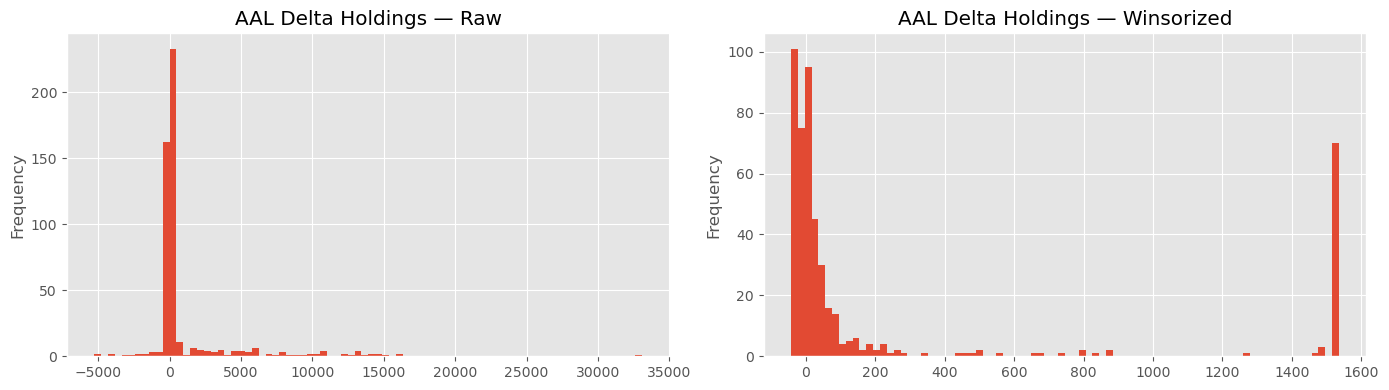

In [61]:
# Winsorize at 2.5% / 97.5% to handle outliers before modeling
# This is your exact scipy winsorize code from the Robinhood notebook

analysis_w = winsorize(analysis.values, limits=[0.025, 0.025])
analysis_w = pd.DataFrame(analysis_w, index=analysis.index, columns=analysis.columns)

# Visual check: compare raw vs winsorized distribution for AAL delta holdings
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
analysis['AAL_delta_holdings'].plot(kind='hist', bins=80, ax=axes[0], title='AAL Delta Holdings — Raw')
analysis_w['AAL_delta_holdings'].plot(kind='hist', bins=80, ax=axes[1], title='AAL Delta Holdings — Winsorized')
plt.tight_layout()
plt.savefig('charts/winsorize_check.png', dpi=150)
plt.show()

In [63]:
# Save both versions to disk
analysis.to_csv(os.path.join(project_root, 'analysis_raw.csv'))
analysis_w.to_csv(os.path.join(project_root, 'analysis_winsorized.csv'))

print('Saved:')
print(f'  analysis_raw.csv        — {analysis.shape}')
print(f'  analysis_winsorized.csv — {analysis_w.shape}')
print()
print('Columns in analysis dataset:')
for col in analysis.columns:
    print(f'  {col}')

Saved:
  analysis_raw.csv        — (497, 45)
  analysis_winsorized.csv — (497, 45)

Columns in analysis dataset:
  F_delta_holdings
  GE_delta_holdings
  AAPL_delta_holdings
  MSFT_delta_holdings
  AAL_delta_holdings
  DIS_delta_holdings
  SPY_delta_holdings
  F_growth_rate_holdings
  GE_growth_rate_holdings
  AAPL_growth_rate_holdings
  MSFT_growth_rate_holdings
  AAL_growth_rate_holdings
  DIS_growth_rate_holdings
  SPY_growth_rate_holdings
  F_spike
  GE_spike
  AAPL_spike
  MSFT_spike
  AAL_spike
  DIS_spike
  SPY_spike
  ('F_returns', 'F')
  ('GE_returns', 'GE')
  ('AAPL_returns', 'AAPL')
  ('MSFT_returns', 'MSFT')
  ('AAL_returns', 'AAL')
  ('DIS_returns', 'DIS')
  ('F_returns', 'F')_mom_5d
  ('F_returns', 'F')_mom_30d
  ('GE_returns', 'GE')_mom_5d
  ('GE_returns', 'GE')_mom_30d
  ('AAPL_returns', 'AAPL')_mom_5d
  ('AAPL_returns', 'AAPL')_mom_30d
  ('MSFT_returns', 'MSFT')_mom_5d
  ('MSFT_returns', 'MSFT')_mom_30d
  ('AAL_returns', 'AAL')_mom_5d
  ('AAL_returns', 'AAL')_mom_30d
 